# Graph Convolutional Networks (GCN)

In [1]:
#| output: false

import sys
from pathlib import Path

# Set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise FileNotFoundError("Could not find 'src' folder above current working directory.")

sys.path.insert(0, str(root))
print("Project root:", root)

Project root: c:\Users\joetn\CS273P_MachineLearning_Final_Project


In [2]:
import json
import joblib
import libpysal
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
import seaborn as sns
from IPython.display import display
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans
import torch

# Import GCN utilities for graph construction, training, and evaluation
from src.gcn import (
    # Reproducibility and device
    set_seed,
    get_device,

    # Graph construction
    build_gcn_support,
    summarize_graph,

    # Data preparation
    stack_split_arrays,
    make_masks,
    numpy_to_torch_features_targets,

    # Model and training
    GCNRegressor,
    build_optimizer,
    train_gcn,
    predict_gcn,
    run_gcn_experiment,

    # Evaluation utilities
    evaluate_regression,
    evaluate_regression_per_target,
    history_to_dataframe,
    results_dict_to_frame,

    # Diagnostics
    count_parameters,
)

# Set plt plotting configs
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.title_fontsize": 9,
    "legend.frameon": True,
    "legend.borderpad": 0.3
})

SEED = 42

In [ ]:
#| output: false

# Load processed data, scalers, and artifacts
processed_dir = Path("../data/processed")
artifacts_dir = Path("../data/artifacts")

# Load county geometries (used later for graph construction and spatial diagnostics)
geo_df = gpd.read_file(processed_dir / "svi_counties.gpkg", layer="counties").copy()

# Ensure FIPS formatting is consistent
geo_df["FIPS"] = geo_df["FIPS"].astype(str).str.zfill(5)

# Load processed split arrays
data = np.load(processed_dir / "svi_processed_splits.npz", allow_pickle=True)

# Log feature pipeline
Xlog_train_scaled = data["Xlog_train_scaled"]
Xlog_val_scaled = data["Xlog_val_scaled"]
Xlog_test_scaled = data["Xlog_test_scaled"]

# Targets
ylog_train_scaled = data["ylog_train_scaled"]
ylog_val_scaled = data["ylog_val_scaled"]
ylog_test_scaled = data["ylog_test_scaled"]

# County identifiers (used for alignment and diagnostics)
fips_train = pd.Series(data["fips_train"]).astype(str).str.zfill(5).to_numpy()
fips_val = pd.Series(data["fips_val"]).astype(str).str.zfill(5).to_numpy()
fips_test = pd.Series(data["fips_test"]).astype(str).str.zfill(5).to_numpy()

# Load scalers (needed to invert predictions later)
scaler_Xlog = joblib.load(processed_dir / "scaler_Xlog.pkl")
scaler_ylog = joblib.load(processed_dir / "scaler_ylog.pkl")

# Concatenate all nodes in modeling order
fips_all = np.concatenate([fips_train, fips_val, fips_test])
X_all = np.vstack([Xlog_train_scaled, Xlog_val_scaled, Xlog_test_scaled])
y_all = np.vstack([ylog_train_scaled, ylog_val_scaled, ylog_test_scaled])

In [6]:
# Basic split and shape checks
assert Xlog_train_scaled.shape[0] == len(fips_train)
assert Xlog_val_scaled.shape[0] == len(fips_val)
assert Xlog_test_scaled.shape[0] == len(fips_test)

assert ylog_train_scaled.shape[0] == len(fips_train)
assert ylog_val_scaled.shape[0] == len(fips_val)
assert ylog_test_scaled.shape[0] == len(fips_test)

assert X_all.shape[0] == len(fips_all)
assert y_all.shape[0] == len(fips_all)

# Check for duplicate FIPS before graph construction
assert pd.Index(fips_all).is_unique
assert pd.Index(geo_df["FIPS"]).is_unique

# Check coverage before reindexing
missing_in_geo = sorted(set(fips_all) - set(geo_df["FIPS"]))
assert len(missing_in_geo) == 0

# Reorder geometry to exact node order for graph construction
geo_graph = geo_df.set_index("FIPS").loc[fips_all].copy()

# Alignment assertions
assert len(geo_graph) == len(fips_all) == X_all.shape[0] == y_all.shape[0]
assert np.array_equal(geo_graph.index.to_numpy(), fips_all)

# Final geometry integrity checks
assert geo_graph.index.is_unique
assert not geo_graph.index.isna().any()
assert geo_graph.geometry.notna().all()

# Alignment diagnostic
alignment_summary = pd.DataFrame(
    {
        "Quantity": [
            "Train counties",
            "Validation counties",
            "Test counties",
            "Total modeled counties",
            "geo_graph counties",
            "Feature columns",
            "Target columns",
        ],
        "Value": [
            len(fips_train),
            len(fips_val),
            len(fips_test),
            len(fips_all),
            len(geo_graph),
            X_all.shape[1],
            y_all.shape[1] if y_all.ndim > 1 else 1,
        ],
    }
)

display(alignment_summary.style.hide(axis="index"))

Quantity,Value
Train counties,2198
Validation counties,471
Test counties,472
Total modeled counties,3141
geo_graph counties,3141
Feature columns,15
Target columns,1


In [11]:
#| output: false

# Load best MLP results
config_df = pd.read_csv(artifacts_dir / "final_mlp_results.csv", index_col=0)

# Clean up labels for readability
config_df.index = (
    config_df.index
    .str.replace("architecture.", "", regex=False)
    .str.replace("regularization.", "", regex=False)
    .str.replace("training.", "", regex=False)
    .str.replace("performance.", "", regex=False)
)

display(config_df.T)

Model,MLP
Feature Pipeline,Log-Transformed Features
Architecture,Deep-128
Hidden Dimensions,"[128, 64, 32]"
Dropout,0.1
Weight Decay,0.00001
Learning Rate,0.001
Trainable Parameters,12417
Epochs Trained,46
Best Epoch,21
Best Validation Loss,0.459419


## Model Motivation

In the previous experiments, a multilayer perceptron (MLP) established a strong non-spatial reference point. However, counties are not independent observations. Neighboring counties often share regional socioeconomic patterns, infrastructure constraints, environmental exposures, and policy contexts. A graph-based model may be able explicitly incorporate this **spatial dependence by treating counties as nodes and county adjacency as edges**. This allows the model to combine each county’s local tabular features with information aggregated from nearby counties. The central motivation for the Graph Convolutional Network (GCN) is therefore to test whether added spatial structure improves predictive performance over the tabular MLP baseline.

## Model formulation

Let $G = (V, E)$ denote a graph where each node $i \in V$ is a county and each edge $(i,j) \in E$ indicates spatial adjacency, such as Queen contiguity. Let $X \in \mathbb{R}^{n \times p}$ be the matrix of county-level predictors and $Y \in \mathbb{R}^{n \times T}$ the matrix of target SVI theme scores for $T$ tasks.

A **graph convolutional network (GCN)** updates node representations by combining transformed node features with neighborhood information. A common layer is

$$
H^{(\ell + 1)} =
\sigma\left(
\tilde{D}^{-1/2}
\tilde{A}
\tilde{D}^{-1/2}
H^{(\ell)}
W^{(\ell)}
\right)
$$

where $H^{(0)} = X$, $\tilde{A} = A + I$ is the adjacency matrix with self-loops, $\tilde{D}$ is the corresponding degree matrix, $W^{(\ell)}$ is a trainable weight matrix, and $\sigma(\cdot)$ is a nonlinear activation function.

For multi-output regression, the final layer produces

$$
\hat{Y} \in \mathbb{R}^{n \times T}
$$

and the model is **trained to minimize a regression loss such as mean squared error (MSE)** over the observed training nodes.

## Baseline configuration carried forward from the MLP stage

The MLP experiments provide a principled reference point for the graph-based models. The current GCN stage preserves as much of that preprocessing and evaluation setup as possible so that performance differences are attributable to the model class and the use of graph structure, rather than changes in the data pipeline.

The main baseline elements carried forward are:

- Log-transformed feature matrix $X_{\log}$
  
- Standardized input features using the training split scaler
  
- Standardized target variables using the training split scaler
  
- Fixed train, validation, and test splits saved from the MLP stage
  
- Multi-output regression setting across SVI themes
  
- Validation-based model selection
  
- Final comparison against the saved best MLP configuration evaluated on the held-out test set

## What the MLP experiments suggest for GCN design

The MLP results suggest several lessons that should inform the GCN experiments.

1) **Regularization should be applied carefully**. In the MLP setting, weight decay was more consistently helpful than large dropout rates. That suggests beginning with modest or no dropout in the GCN and treating weight decay as the primary regularizer.

2) Preserving representational capacity matters. Since dropout can suppress useful structured signal, especially in relatively small or smooth datasets, the first GCN trials should **prioritize stable hidden dimensions and shallow architectures** before adding stronger regularization.

3) **Comparisons should be made under matched conditions**. Because the MLP already used tuned preprocessing and consistent splits, GCN experiments should reuse these exact artifacts and evaluate improvements relative to the saved best MLP configuration.

## Ablation plan

To keep the GCN stage focused and interpretable, the ablation study will prioritize three high-value dimensions: graph depth, hidden representation size, and regularization strength. These ablations are the most informative because they directly test whether spatial message passing is beneficial, how much model capacity is needed, and how strongly the graph model should be regularized given the earlier MLP results. 

Much like the MLP experiments, each ablation category is varied at a time while the others are held fixed. After identifying the best setting within that category, that value is retained for the next ablation stage. This strategy is computationally feasible and produces an interpretable progression of model refinements. However, it may miss certain hyperparameter interactions that could be identified through a full grid search.

### Number of GCN layers

 The first ablation varies the number of graph convolution layers, such as 1, 3, and 5 layers. Each additional layer expands the receptive field and allows a county representation to incorporate information from more distant neighbors. At the same time, deeper graph models can suffer from oversmoothing, where node representations become too similar and predictive signal is lost. This ablation directly tests how much spatial propagation is actually useful for SVI regression.

### Hidden dimension

 The second ablation varies the hidden dimension, such as 16, 32, and 64 units. This controls the representational capacity of the model and determines how flexibly the GCN can learn nonlinear combinations of county-level and neighborhood-level information. If the hidden size is too small, the model may underfit and fail to capture meaningful spatial structure. If it is too large, the model may overfit or introduce unnecessary complexity. This ablation helps identify an appropriate capacity level for the county graph.

### Regularization strength

 The third ablation focuses on regularization much like the MLP ablations, primarily through weight decay and secondarily through a small dropout range. The earlier MLP experiments suggested that weight decay was more consistently helpful than aggressive dropout, so the GCN experiments emphasizes weight decay as the main regularization mechanism while keeping dropout modest. The setup varies weight decay across values such as $0.0$, $10^{-3}$, and $10^{-5}$, while testing dropout values such as $0.0$, $0.1$, and $0.3$. This ablation evaluates whether the GCN benefits from the same regularization pattern observed in the non-spatial baseline.

In [5]:
#| label: tbl-split-summary
#| tbl-cap: "Shapes of the processed train, validation, and test arrays used for GCN modeling."
#| output: false

# Data validation
split_summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "X Shape": [
            Xlog_train_scaled.shape,
            Xlog_val_scaled.shape,
            Xlog_test_scaled.shape,
        ],
        "y Shape": [
            y_train_scaled.shape,
            y_val_scaled.shape,
            y_test_scaled.shape,
        ],
    }
)

display(split_summary.style.hide(axis="index"))

Split,X Shape,y Shape
Train,"(2200, 16)","(2200, 4)"
Validation,"(472, 16)","(472, 4)"
Test,"(472, 16)","(472, 4)"


In [6]:
#| label: tbl-geo-summary
#| tbl-cap: "Basic summary of the county geometry file used to construct the spatial graph."
#| output: false

# Keep only aligned node IDs and geometry in the exact modeling order
geo_graph = geo_df.set_index("FIPS").loc[fips_all, ["geometry"]].copy()

# Drop missing geometries if any
geo_graph = geo_graph[geo_graph.geometry.notnull()].copy()

# Data validation
geo_summary = pd.DataFrame(
    {
        "Metric": [
            "Number of counties",
            "Number of columns",
            "CRS",
            "Node order aligned to splits",
        ],
        "Value": [
            len(geo_graph),
            geo_graph.shape[1],
            str(geo_graph.crs),
            np.array_equal(geo_graph.index.to_numpy(), fips_all[:len(geo_graph)]),
        ],
    }
)

display(geo_summary.style.hide(axis="index"))

Metric,Value
Number of counties,3144
Number of columns,1
CRS,EPSG:4269
Node order aligned to splits,True


In [7]:
#| label: tbl-queen-graph-summary
#| tbl-cap: "Summary of the Queen contiguity graph constructed from county geometries."
#| output: false

set_seed(SEED)

# Build graph support using the geometry already aligned to fips_all order
adjacency_raw, adjacency_norm, adjacency_torch, queen_w = build_gcn_support(
    geo_df=geo_graph,
    id_column=None,
    add_loops=True,
    use_index=True,
)

graph_summary = summarize_graph(adjacency_raw)
display(graph_summary.style.hide(axis="index"))

c:\Users\joetn\anaconda3\envs\svi\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
 There are 3 islands with ids: 15003, 15001, 15007.
  W.__init__(self, neighbors, ids=ids, **kw)


n_nodes,n_edges_undirected,degree_min,degree_mean,degree_median,degree_max,n_isolated_nodes
3144,9288,0.000000,5.908397,6.000000,14.000000,3


In [8]:
# Stack arrays in train -> val -> test order
X_all, y_all, train_idx, val_idx, test_idx, node_order, split_ids, split_sizes = stack_split_arrays(
    X_train=Xlog_train_scaled,
    X_val=Xlog_val_scaled,
    X_test=Xlog_test_scaled,
    y_train=y_train_scaled,
    y_val=y_val_scaled,
    y_test=y_test_scaled,
)

# Create boolean masks that identify which graph nodes belong to each split
train_mask, val_mask, test_mask = make_masks(
    n_nodes=X_all.shape[0],
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
)

In [9]:
# Select the computation device
device = get_device()

# Convert the stacked feature and target arrays to PyTorch tensors
X_t, y_t = numpy_to_torch_features_targets(X_all, y_all, device=device)

# Move graph objects and masks to the same device
adjacency_torch = adjacency_torch.to(device)
train_mask = train_mask.to(device)
val_mask = val_mask.to(device)
test_mask = test_mask.to(device)

assert X_t.shape[0] == adjacency_torch.shape[0] == adjacency_torch.shape[1]
assert y_t.shape[0] == X_t.shape[0]
assert y_t.shape[1] == 4

In [10]:
#| label: tbl-gcn-baseline-config
#| tbl-cap: "Initial baseline configuration for the baseline GCN."

# Define a conservative baseline GCN configuration informed by the MLP results
base_gcn_config = {
    "num_layers": 1,
    "hidden_dim": 64,
    "dropout": 0.0,
    "weight_decay": 1e-3,
    "lr": 1e-3,
    "n_epochs": 300, 
    "patience": 25,
    "seed": SEED,
}

target_cols = ["RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4"]

# Display the baseline configuration
gcn_baseline_config_df = pd.DataFrame(
    {
        "Hyperparameter": list(base_gcn_config.keys()),
        "Value": list(base_gcn_config.values()),
    }
)

display(gcn_baseline_config_df.style.format({"Value": lambda x: f"{x:.0e}" if isinstance(x, float) and x < 0.01 else x})
    .hide(axis="index"))

Hyperparameter,Value
num_layers,1.0
hidden_dim,64.0
dropout,0e+00
weight_decay,1e-03
lr,1e-03
n_epochs,300.0
patience,25.0
seed,42.0


In [12]:
#| output: false

baseline_gcn_results = run_gcn_experiment(
    adjacency=adjacency_torch,
    X=X_t,
    y=y_t,
    train_mask=train_mask,
    val_mask=val_mask,
    hidden_dim=base_gcn_config["hidden_dim"],
    num_layers=base_gcn_config["num_layers"],
    dropout=base_gcn_config["dropout"],
    lr=base_gcn_config["lr"],
    weight_decay=base_gcn_config["weight_decay"],
    n_epochs=base_gcn_config["n_epochs"],
    patience=base_gcn_config["patience"],
    seed=base_gcn_config["seed"],
    target_names=target_cols,
    scaler_y=scaler_y,
    verbose=False,
    evaluate_test=False,
)

In [13]:
#| label: tbl-gcn-training-summary
#| tbl-cap: "Training summary for the baseline GCN experiment, including the best validation epoch and parameter count."

# Summarize key training results from the baseline GCN run
gcn_training_summary = pd.DataFrame(
    {
        "Metric": [
            "Best validation epoch",
            "Best validation loss",
            "Number of trainable parameters",
        ],
        "Value": [
            baseline_gcn_results["history"].best_epoch,
            baseline_gcn_results["history"].best_val_loss,
            baseline_gcn_results["config"]["n_parameters"],
        ],
    }
)

display(gcn_training_summary.style.hide(axis="index"))

Metric,Value
Best validation epoch,299.000000
Best validation loss,0.565890
Number of trainable parameters,68.000000


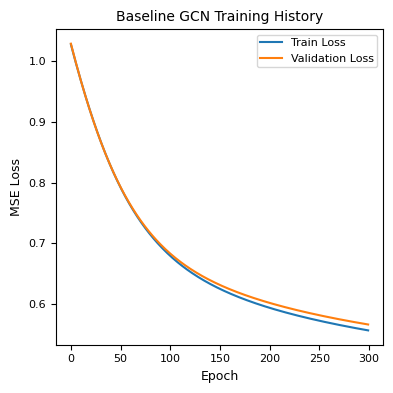

In [14]:
#| label: fig-gcn-training-history
#| fig-cap: "Training and validation loss curves for the baseline GCN model."

# Convert the saved training history to a DataFrame for plotting
history_df = baseline_gcn_results["history_df"]

# Plot train and validation loss across epochs
fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
ax.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")

ax.set_title("Baseline GCN Training History")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()

plt.tight_layout()
plt.show()

In [17]:
#| label: tbl-gcn-baseline-per-target
#| tbl-cap: "Per-target validation metrics for the baseline GCN model across the four SVI theme targets."
#| output: false

# Extract per-target validation metrics
gcn_val_per_target = baseline_gcn_results["val_metrics_per_target"].copy()

# Keep only the selected metrics
gcn_val_per_target = gcn_val_per_target[["Target", "RMSE", "R2"]]

display(gcn_val_per_target.style.hide(axis="index"))

Target,RMSE,R2
RPL_THEME1,0.174090,0.635325
RPL_THEME2,0.237472,0.296127
RPL_THEME3,0.188526,0.574840
RPL_THEME4,0.259329,0.221174


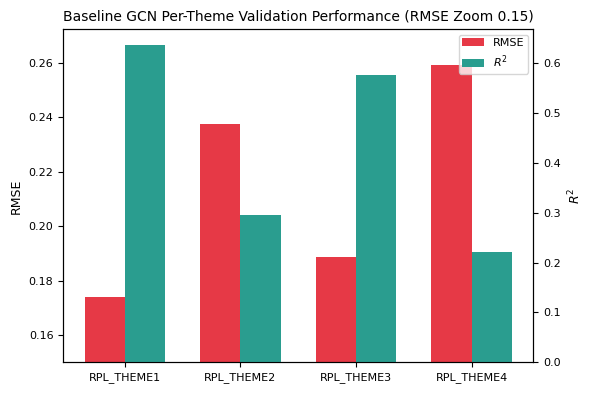

In [20]:
#| label: fig-gcn-theme-performance
#| fig-cap: "Baseline GCN per-theme validation performance showing RMSE and $R^2$ for each SVI theme on the validation split."

# Extract per-theme validation metrics
theme_metrics = baseline_gcn_results["val_metrics_per_target"].copy()

themes = theme_metrics["Target"].values
rmse_vals = theme_metrics["RMSE"].values
r2_vals = theme_metrics["R2"].values

x = np.arange(len(themes))
width = 0.35

fig, ax1 = plt.subplots(figsize=(6, 4))

# RMSE bars (left axis)
bars1 = ax1.bar(
    x - width / 2,
    rmse_vals,
    width,
    label="RMSE",
    color="#e63946"
)

ax1.set_ylabel("RMSE")
ax1.set_xticks(x)
ax1.set_xticklabels(themes)
ax1.set_title("Baseline GCN Per-Theme Validation Performance (RMSE Zoom 0.15)")

ax1.set_ylim(0.15)

# R² bars (right axis)
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width / 2,
    r2_vals,
    width,
    label="$R^2$",
    color="#2a9d8f"
)

ax2.set_ylabel("$R^2$")
# ax2.set_ylim(0.2, 1.0)

# Legend
ax1.legend(
    [bars1[0], bars2[0]],
    ["RMSE", "$R^2$"],
    loc="upper right"
)

plt.tight_layout()
plt.show()

## Layer Ablation

In [21]:
#| label: tbl-gcn-layer-ablation-grid
#| tbl-cap: "Layer configurations evaluated in the first GCN ablation stage."
#| output: false

layer_candidates = [1, 2, 3]

layer_ablation_df = pd.DataFrame({"num_layers": layer_candidates})
display(layer_ablation_df.style.hide(axis="index"))

num_layers
1
2
3


In [22]:
#| output: false

layer_results = []

for num_layers in layer_candidates:
    result = run_gcn_experiment(
        adjacency=adjacency_torch,
        X=X_t,
        y=y_t,
        train_mask=train_mask,
        val_mask=val_mask,
        hidden_dim=base_gcn_config["hidden_dim"],
        num_layers=num_layers,
        dropout=base_gcn_config["dropout"],
        lr=base_gcn_config["lr"],
        weight_decay=base_gcn_config["weight_decay"],
        n_epochs=base_gcn_config["n_epochs"],
        patience=base_gcn_config["patience"],
        seed=base_gcn_config["seed"],
        target_names=target_cols,
        scaler_y=scaler_y,
        verbose=False,
        evaluate_test=False,
    )

    layer_results.append(
        {
            "num_layers": num_layers,
            "val_RMSE": result["val_metrics"].iloc[0]["RMSE"],
            "val_R2": result["val_metrics"].iloc[0]["R2"],
        }
    )

In [23]:
#| label: tbl-gcn-layer-ablation-results
#| tbl-cap: "GCN layer ablation results with all other hyperparameters held fixed."
#| output: false

layer_results_df = (
    pd.DataFrame(layer_results)
    .sort_values("num_layers")
    .reset_index(drop=True)
)

display(layer_results_df.style.hide(axis="index"))

num_layers,val_RMSE,val_R2
1,0.217655,0.431867
2,0.191753,0.559353
3,0.202469,0.509027


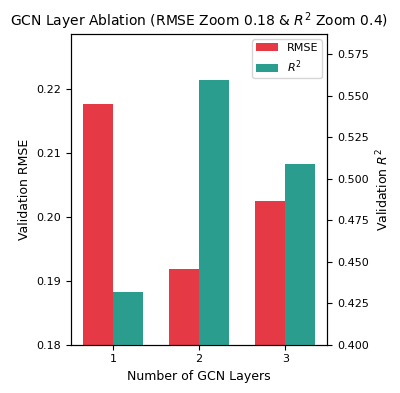

In [24]:
#| label: fig-gcn-layer-ablation
#| fig-cap: "Validation RMSE and $R^2$ across different GCN layer depths."

layers = layer_results_df["num_layers"].values
rmse_vals = layer_results_df["val_RMSE"].values
r2_vals = layer_results_df["val_R2"].values

x = np.arange(len(layers))
width = 0.35

fig, ax1 = plt.subplots(figsize=(4,4))

# RMSE bars
bars1 = ax1.bar(
    x - width/2,
    rmse_vals,
    width,
    label="RMSE",
    color="#e63946"
)

ax1.set_ylabel("Validation RMSE")
ax1.set_xticks(x)
ax1.set_xticklabels(layers)
ax1.set_xlabel("Number of GCN Layers")
ax1.set_title("GCN Layer Ablation (RMSE Zoom 0.18 & $R^2$ Zoom 0.4)")
ax1.set_ylim(0.18) 

# R² bars
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    r2_vals,
    width,
    label="$R^2$",
    color="#2a9d8f"
)

ax2.set_ylabel("Validation $R^2$")
ax2.set_ylim(0.4) 

# Legend
ax1.legend(
    [bars1[0], bars2[0]],
    ["RMSE", "$R^2$"],
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [25]:
# Select the best layer configuration using validation RMSE
best_num_layers = int(
    layer_results_df.loc[layer_results_df["val_RMSE"].idxmin(), "num_layers"]
)

# Update base configuration with the best number of layers
base_gcn_config["num_layers"] = best_num_layers

## Hidden Dimension Ablation

In [26]:
#| label: tbl-gcn-hidden-ablation-grid
#| tbl-cap: "Hidden dimension configurations evaluated in the second GCN ablation stage."
#| output: false

hidden_candidates = [32, 64, 128]

hidden_ablation_df = pd.DataFrame({"hidden_dim": hidden_candidates})
display(hidden_ablation_df.style.hide(axis="index"))

hidden_dim
32
64
128


In [27]:
#| output: false

hidden_results = []

for hidden_dim in hidden_candidates:
    result = run_gcn_experiment(
        adjacency=adjacency_torch,
        X=X_t,
        y=y_t,
        train_mask=train_mask,
        val_mask=val_mask,
        hidden_dim=hidden_dim,
        num_layers=best_num_layers,
        dropout=base_gcn_config["dropout"],
        lr=base_gcn_config["lr"],
        weight_decay=base_gcn_config["weight_decay"],
        n_epochs=base_gcn_config["n_epochs"],
        patience=base_gcn_config["patience"],
        seed=base_gcn_config["seed"],
        target_names=target_cols,
        scaler_y=scaler_y,
        verbose=False,
        evaluate_test=False,
    )

    hidden_results.append(
        {
            "hidden_dim": hidden_dim,
            "val_RMSE": result["val_metrics"].iloc[0]["RMSE"],
            "val_R2": result["val_metrics"].iloc[0]["R2"],
        }
    )

In [28]:
#| label: tbl-gcn-hidden-ablation-results
#| tbl-cap: "GCN hidden dimension ablation results using the best layer configuration from the previous stage."
#| output: false

hidden_results_df = (
    pd.DataFrame(hidden_results)
    .sort_values("hidden_dim")
    .reset_index(drop=True)
)

display(hidden_results_df.style.hide(axis="index"))

hidden_dim,val_RMSE,val_R2
32,0.194738,0.545266
64,0.191753,0.559353
128,0.190981,0.562841


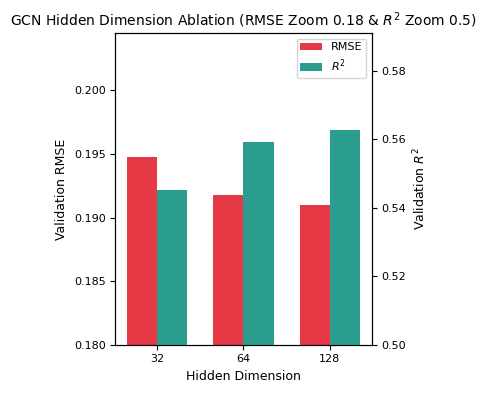

In [29]:
#| label: fig-gcn-hidden-ablation
#| fig-cap: "Validation RMSE and $R^2$ across different GCN hidden dimensions."

hidden_dims = hidden_results_df["hidden_dim"].values
rmse_vals = hidden_results_df["val_RMSE"].values
r2_vals = hidden_results_df["val_R2"].values

x = np.arange(len(hidden_dims))
width = 0.35

fig, ax1 = plt.subplots(figsize=(4,4))

# RMSE bars
bars1 = ax1.bar(
    x - width/2,
    rmse_vals,
    width,
    label="RMSE",
    color="#e63946"
)

ax1.set_ylabel("Validation RMSE")
ax1.set_ylim(0.18)
ax1.set_xticks(x)
ax1.set_xticklabels(hidden_dims)
ax1.set_xlabel("Hidden Dimension")
ax1.set_title("GCN Hidden Dimension Ablation (RMSE Zoom 0.18 & $R^2$ Zoom 0.5)")

# R² bars
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    r2_vals,
    width,
    label="$R^2$",
    color="#2a9d8f"
)

ax2.set_ylabel("Validation $R^2$")
ax2.set_ylim(0.5) 

# Legend
ax1.legend(
    [bars1[0], bars2[0]],
    ["RMSE", "$R^2$"],
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [30]:
# Select the best hidden dimension based on validation RMSE
best_hidden_dim = int(hidden_results_df.loc[hidden_results_df["val_RMSE"].idxmin(), "hidden_dim"])

# Update base configuration with the best number of layers
base_gcn_config["hidden_dim"] = best_hidden_dim

## Regularization Ablation

### Weight Decay Ablation

In [31]:
#| label: tbl-gcn-weight-decay-grid
#| tbl-cap: "Weight decay configurations evaluated in the GCN regularization ablation."
#| output: false

weight_decay_candidates = [0.0,  1e-5, 1e-3]

weight_decay_df = pd.DataFrame({"weight_decay": weight_decay_candidates})
display(weight_decay_df.style.format({"weight_decay": "{:.0e}"}).hide(axis="index"))

weight_decay
0e+00
1e-05
1e-03


In [32]:
#| output: false

weight_decay_results = []

for wd in weight_decay_candidates:

    result = run_gcn_experiment(
        adjacency=adjacency_torch,
        X=X_t,
        y=y_t,
        train_mask=train_mask,
        val_mask=val_mask,
        hidden_dim=best_hidden_dim,
        num_layers=best_num_layers,
        dropout=0.0,
        lr=base_gcn_config["lr"],
        weight_decay=wd,
        n_epochs=base_gcn_config["n_epochs"],
        patience=base_gcn_config["patience"],
        seed=base_gcn_config["seed"],
        target_names=target_cols,
        scaler_y=scaler_y,
        verbose=False,
        evaluate_test=False,
    )

    weight_decay_results.append(
        {
            "weight_decay": wd,
            "val_RMSE": result["val_metrics"].iloc[0]["RMSE"],
            "val_R2": result["val_metrics"].iloc[0]["R2"],
        }
    )

In [33]:
#| label: tbl-gcn-weight-decay-results
#| tbl-cap: "GCN weight decay ablation results."
#| output: false

weight_decay_results_df = (
    pd.DataFrame(weight_decay_results)
    .sort_values("weight_decay")
    .reset_index(drop=True)
)

display(weight_decay_results_df.style.format({"weight_decay": "{:.0e}"}).hide(axis="index"))

weight_decay,val_RMSE,val_R2
0e+00,0.191134,0.562150
1e-05,0.191125,0.562196
1e-03,0.190981,0.562841


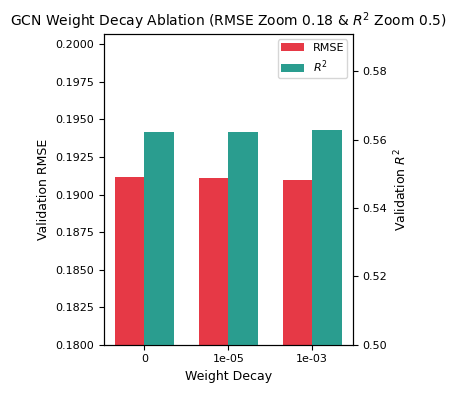

In [34]:
#| label: fig-gcn-weight-decay-ablation
#| fig-cap: "Validation RMSE and $R^2$ across weight decay values."

wd_vals = weight_decay_results_df["weight_decay"].values
rmse_vals = weight_decay_results_df["val_RMSE"].values
r2_vals = weight_decay_results_df["val_R2"].values

x = np.arange(len(wd_vals))
width = 0.35

fig, ax1 = plt.subplots(figsize=(4,4))

bars1 = ax1.bar(
    x - width/2,
    rmse_vals,
    width,
    label="RMSE",
    color="#e63946"
)

ax1.set_ylabel("Validation RMSE")
ax1.set_xticks(x)
labels = ["0" if v == 0 else f"{v:.0e}" for v in wd_vals]
ax1.set_xticklabels(labels)
ax1.set_xlabel("Weight Decay")
ax1.set_title("GCN Weight Decay Ablation (RMSE Zoom 0.18 & $R^2$ Zoom 0.5)")
ax1.set_ylim(0.18) 

ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    r2_vals,
    width,
    label="$R^2$",
    color="#2a9d8f"
)

ax2.set_ylabel("Validation $R^2$")
ax2.set_ylim(0.5) 

ax1.legend(
    [bars1[0], bars2[0]],
    ["RMSE", "$R^2$"],
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [35]:
# Select the best weight decay based on validation RMSE
best_weight_decay = float(
    weight_decay_results_df.loc[
        weight_decay_results_df["val_RMSE"].idxmin(), "weight_decay"
    ]
)

# Update base configuration with the best number of layers
base_gcn_config["weight_decay"] = best_weight_decay

### Dropout Ablation

In [36]:
#| label: tbl-gcn-dropout-grid
#| tbl-cap: "Dropout configurations evaluated after selecting the best weight decay."
#| output: false

dropout_candidates = [0.0, 0.1, 0.3]

dropout_df = pd.DataFrame({"dropout": dropout_candidates})
display(dropout_df.style.format({"dropout": "{:.1e}"}))

,dropout
0,0.0e+00
1,1.0e-01
2,3.0e-01


In [37]:
#| output: false

dropout_results = []

for dropout in dropout_candidates:

    result = run_gcn_experiment(
        adjacency=adjacency_torch,
        X=X_t,
        y=y_t,
        train_mask=train_mask,
        val_mask=val_mask,
        hidden_dim=best_hidden_dim,
        num_layers=best_num_layers,
        dropout=dropout,
        lr=base_gcn_config["lr"],
        weight_decay=best_weight_decay,
        n_epochs=base_gcn_config["n_epochs"],
        patience=base_gcn_config["patience"],
        seed=base_gcn_config["seed"],
        target_names=target_cols,
        scaler_y=scaler_y,
        verbose=False,
        evaluate_test=False,
    )

    dropout_results.append(
        {
            "dropout": dropout,
            "val_RMSE": result["val_metrics"].iloc[0]["RMSE"],
            "val_R2": result["val_metrics"].iloc[0]["R2"],
        }
    )

In [38]:
#| label: tbl-gcn-dropout-results
#| tbl-cap: "GCN dropout ablation results with the best weight decay applied."
#| output: false

dropout_results_df = (
    pd.DataFrame(dropout_results)
    .sort_values("dropout")
    .reset_index(drop=True)
)

display(dropout_results_df.style.format({"dropout": "{:.1e}"}).hide(axis="index"))

dropout,val_RMSE,val_R2
0.0e+00,0.190981,0.562841
1.0e-01,0.190994,0.562774
3.0e-01,0.191082,0.562350


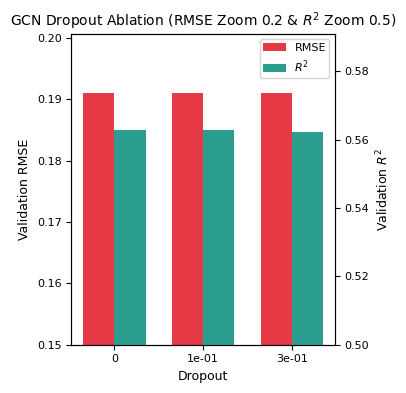

In [39]:
#| label: fig-gcn-dropout-ablation
#| fig-cap: "Validation RMSE and $R^2$ across dropout values."

drop_vals = dropout_results_df["dropout"].values
rmse_vals = dropout_results_df["val_RMSE"].values
r2_vals = dropout_results_df["val_R2"].values

x = np.arange(len(drop_vals))
width = 0.35

fig, ax1 = plt.subplots(figsize=(4,4))

bars1 = ax1.bar(
    x - width/2,
    rmse_vals,
    width,
    label="RMSE",
    color="#e63946"
)

ax1.set_ylabel("Validation RMSE")
ax1.set_xticks(x)
labels = ["0" if v == 0 else f"{v:.0e}" for v in drop_vals]
ax1.set_xticklabels(labels)
ax1.set_xlabel("Dropout")
ax1.set_title("GCN Dropout Ablation (RMSE Zoom 0.2 & $R^2$ Zoom 0.5)")
ax1.set_ylim(0.15) 

ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    r2_vals,
    width,
    label="$R^2$",
    color="#2a9d8f"
)

ax2.set_ylabel("Validation $R^2$")
ax2.set_ylim(0.5) 

ax1.legend(
    [bars1[0], bars2[0]],
    ["RMSE", "$R^2$"],
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [40]:
# Select the best dropout using validation RMSE
best_dropout = float(
    dropout_results_df.loc[
        dropout_results_df["val_RMSE"].idxmin(), "dropout"
    ]
)

# Update base configuration with the best number of layers
base_gcn_config["dropout"] = best_dropout

# Final Model Comparisons

In [42]:
# Best gcn config
final_gcn_config = {
    "num_layers": best_num_layers,
    "hidden_dim": best_hidden_dim,
    "weight_decay": best_weight_decay,
    "dropout": best_dropout,
    "lr": base_gcn_config["lr"],
    "n_epochs": base_gcn_config["n_epochs"],
    "patience": base_gcn_config["patience"],
    "seed": base_gcn_config["seed"],
}

In [43]:
#| output: false

# Run the final GCN using the selected configuration on held-out test set
final_gcn_results = run_gcn_experiment(
    adjacency=adjacency_torch,
    X=X_t,
    y=y_t,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
    hidden_dim=final_gcn_config["hidden_dim"],
    num_layers=final_gcn_config["num_layers"],
    dropout=final_gcn_config["dropout"],
    lr=final_gcn_config["lr"],
    weight_decay=final_gcn_config["weight_decay"],
    n_epochs=final_gcn_config["n_epochs"],
    patience=final_gcn_config["patience"],
    seed=final_gcn_config["seed"],
    target_names=target_cols,
    scaler_y=scaler_y,
    verbose=False,
    evaluate_test=True,
)

In [ ]:
#| label: tbl-mlp-gcn-comparison
#| tbl-cap: "Test-set comparison between the best MLP baseline and the final GCN model."
#| output: false

# Extract best MLP overall test metrics
mlp_test_rmse = best_mlp_config["performance"]["overall_rmse"]
mlp_test_r2 = best_mlp_config["performance"]["overall_r2"]

# Extract final GCN overall test metrics
gcn_test_rmse = final_gcn_results["test_metrics"]["RMSE"].iloc[0]
gcn_test_r2 = final_gcn_results["test_metrics"]["R2"].iloc[0]

# Build comparison table
model_comparison_df = pd.DataFrame(
    {
        "Model": ["Best MLP", "Best GCN"],
        "Test RMSE": [mlp_test_rmse, gcn_test_rmse],
        "Test R2": [mlp_test_r2, gcn_test_r2],
    }
)

display(
    model_comparison_df.style
    .format({
        "Test RMSE": "{:.6f}",
        "Test R2": "{:.6f}",
    })
    .hide(axis="index")
)

Model,Test RMSE,Test R2
Best MLP,0.022648,0.993763
Best GCN,0.192155,0.548796


In [50]:
#| label: tbl-final-model-config-comparison
#| tbl-cap: "Configuration comparison between the best MLP baseline and the best GCN model."
#| output: false

best_gcn_config = final_gcn_results["config"]

mlp_params = best_mlp_config["architecture"]["trainable_parameters"]
gcn_params = best_gcn_config["n_parameters"]

config_comparison_df = pd.DataFrame(
    {
        "Configuration": [
            "Feature Pipeline",
            "Architecture",
            "Variant / Layers",
            "Hidden Dim",
            "Dropout",
            "Weight Decay",
            "Learning Rate",
            "Optimizer",
            "Max Epochs",
            "Early Stopping",
            "Parameter Count",
        ],
        "Best MLP": [
            best_mlp_config["feature_pipeline"],
            best_mlp_config["architecture"]["model"],
            best_mlp_config["architecture"]["variant"],
            best_mlp_config["architecture"]["hidden_layers"][0],
            best_mlp_config["architecture"]["dropout"],
            best_mlp_config["regularization"]["weight_decay"],
            best_mlp_config["training"]["learning_rate"],
            best_mlp_config["training"]["optimizer"],
            best_mlp_config["training"]["max_epochs"],
            best_mlp_config["training"]["early_stopping_patience"],
            mlp_params,
        ],
        "Best GCN": [
            "log-transformed EP_*",
            "GCN",
            f'{best_gcn_config["num_layers"]} layer(s)',
            best_gcn_config["hidden_dim"],
            best_gcn_config["dropout"],
            best_gcn_config["weight_decay"],
            best_gcn_config["lr"],
            "Adam",
            best_gcn_config["n_epochs"],
            best_gcn_config["patience"],
            gcn_params,
        ],
    }
)

display(
    config_comparison_df.style
    .format({
        "Best MLP": lambda x: f"{x:.0e}" if isinstance(x, float) and x < 0.01 else x,
        "Best GCN": lambda x: f"{x:.0e}" if isinstance(x, float) and x < 0.01 else x,
    })
    .hide(axis="index")
)

Configuration,Best MLP,Best GCN
Feature Pipeline,log-transformed EP_*,log-transformed EP_*
Architecture,MLP,GCN
Variant / Layers,Deep-256,2 layer(s)
Hidden Dim,256,128
Dropout,0e+00,0e+00
Weight Decay,1e-03,1e-03
Learning Rate,1e-03,1e-03
Optimizer,Adam,Adam
Max Epochs,300,300
Early Stopping,25,25


In [53]:
#| label: tbl-mlp-gcn-per-theme-comparison
#| tbl-cap: "Per-theme test-set comparison between the best MLP baseline and the best GCN model."
#| output: false

gcn_per_theme_df = final_gcn_results["test_metrics_per_target"].copy()

mlp_per_theme_df = pd.DataFrame(
    [
        {
            "Target": "RPL_THEME1",
            "MLP RMSE": best_mlp_config["performance"]["per_theme"]["RPL_THEME1"]["rmse"],
            "MLP R2": best_mlp_config["performance"]["per_theme"]["RPL_THEME1"]["r2"],
        },
        {
            "Target": "RPL_THEME2",
            "MLP RMSE": best_mlp_config["performance"]["per_theme"]["RPL_THEME2"]["rmse"],
            "MLP R2": best_mlp_config["performance"]["per_theme"]["RPL_THEME2"]["r2"],
        },
        {
            "Target": "RPL_THEME3",
            "MLP RMSE": best_mlp_config["performance"]["per_theme"]["RPL_THEME3"]["rmse"],
            "MLP R2": best_mlp_config["performance"]["per_theme"]["RPL_THEME3"]["r2"],
        },
        {
            "Target": "RPL_THEME4",
            "MLP RMSE": best_mlp_config["performance"]["per_theme"]["RPL_THEME4"]["rmse"],
            "MLP R2": best_mlp_config["performance"]["per_theme"]["RPL_THEME4"]["r2"],
        },
    ]
)

per_theme_comparison_df = (
    mlp_per_theme_df.merge(
        gcn_per_theme_df[["Target", "RMSE", "R2"]],
        on="Target",
        how="inner",
    )
    .rename(columns={"RMSE": "GCN RMSE", "R2": "GCN R2"})
)

display(
    per_theme_comparison_df.style
    .format({
        "MLP RMSE": "{:.6f}",
        "MLP R2": "{:.6f}",
        "GCN RMSE": "{:.6f}",
        "GCN R2": "{:.6f}",
    })
    .hide(axis="index")
)

Target,MLP RMSE,MLP R2,GCN RMSE,GCN R2
RPL_THEME1,0.020721,0.994857,0.180326,0.610482
RPL_THEME2,0.029879,0.988840,0.218847,0.401282
RPL_THEME3,0.014371,0.997529,0.140943,0.762309
RPL_THEME4,0.022873,0.993613,0.217756,0.421112


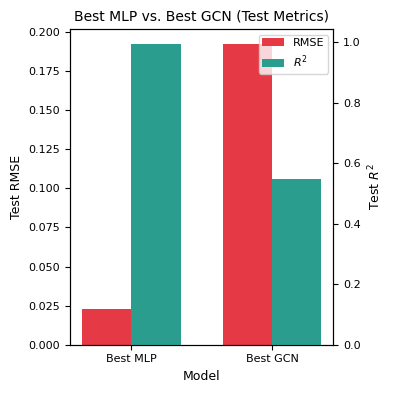

In [60]:
#| label: fig-mlp-gcn-overall-comparison
#| fig-cap: "Overall held-out test-set comparison between the best MLP baseline and the final GCN model."

rmse_vals = model_comparison_df["Test RMSE"].to_numpy(dtype=float)
r2_vals = model_comparison_df["Test R2"].to_numpy(dtype=float)
models = model_comparison_df["Model"].to_numpy()

x = np.arange(len(models))
width = 0.35

fig, ax1 = plt.subplots(figsize=(4, 4))

bars1 = ax1.bar(
    x - width / 2,
    rmse_vals,
    width,
    label="RMSE",
    color="#e63946"
)

ax1.set_ylabel("Test RMSE")
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_xlabel("Model")
ax1.set_title("Best MLP vs. Best GCN (Test Metrics)")

ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width / 2,
    r2_vals,
    width,
    label="$R^2$",
    color="#2a9d8f"
)

ax2.set_ylabel("Test $R^2$")
ax2.set_ylim()

ax1.legend(
    [bars1[0], bars2[0]],
    ["RMSE", "$R^2$"],
    loc="upper right"
)

plt.tight_layout()
plt.show()

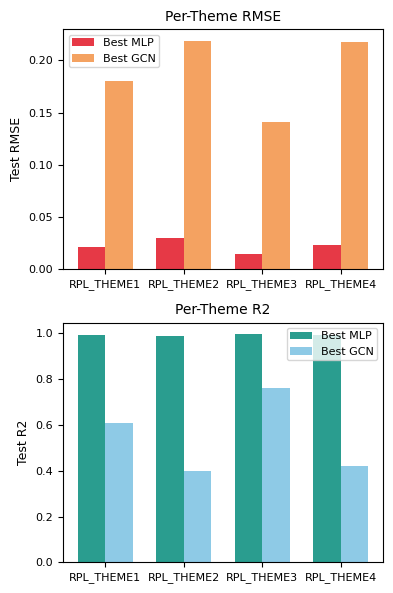

In [61]:
#| label: fig-mlp-gcn-per-theme-comparison
#| fig-cap: "Per-theme test-set comparison between the best MLP baseline and the best GCN model."

theme_labels = per_theme_comparison_df["Target"].values
x = np.arange(len(theme_labels))
width = 0.35

fig, axes = plt.subplots(2, 1, figsize=(4, 6))

# RMSE subplot
axes[0].bar(
    x - width/2,
    per_theme_comparison_df["MLP RMSE"].values,
    width,
    label="Best MLP",
    color="#e63946"
)
axes[0].bar(
    x + width/2,
    per_theme_comparison_df["GCN RMSE"].values,
    width,
    label="Best GCN",
    color="#f4a261"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(theme_labels, rotation=0)
axes[0].set_ylabel("Test RMSE")
axes[0].set_title("Per-Theme RMSE")
axes[0].legend()

# R2 subplot
axes[1].bar(
    x - width/2,
    per_theme_comparison_df["MLP R2"].values,
    width,
    label="Best MLP",
    color="#2a9d8f"
)
axes[1].bar(
    x + width/2,
    per_theme_comparison_df["GCN R2"].values,
    width,
    label="Best GCN",
    color="#8ecae6"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(theme_labels, rotation=0)
axes[1].set_ylabel("Test R2")
axes[1].set_title("Per-Theme R2")
axes[1].legend()

plt.tight_layout()
plt.show()